In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

GOLD_DAILY_PATH = "../data/processed/gold_daily_scope.csv"
daily_scope = pd.read_csv(GOLD_DAILY_PATH, parse_dates=["Date"])

daily_scope.head()
daily_scope["Emission_Type"].value_counts()


Emission_Type
Scope 1    2192
Scope 2    2192
Name: count, dtype: int64

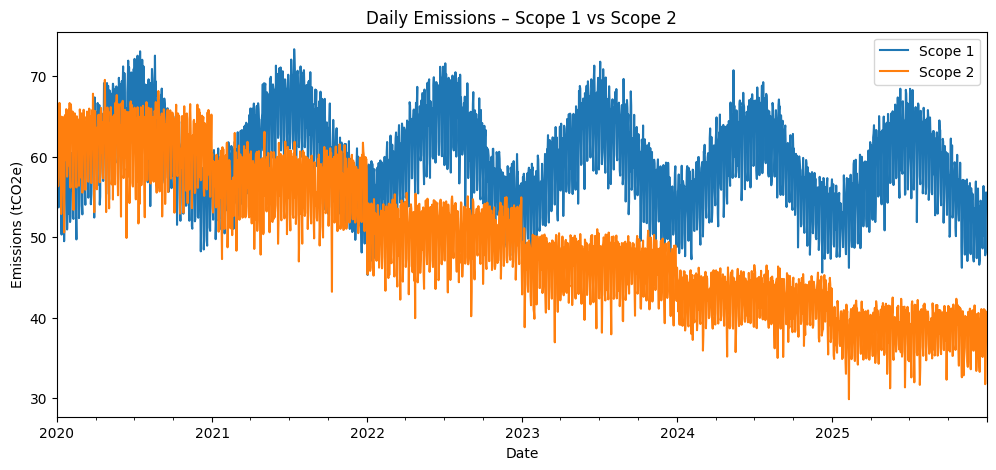

In [3]:
plt.figure(figsize=(12, 5))
for scope in ["Scope 1", "Scope 2"]:
    mask = daily_scope["Emission_Type"] == scope
    series = (daily_scope[mask]
              .set_index("Date")["Emissions_tCO2e"]
              .sort_index())
    series.plot(label=scope)

plt.title("Daily Emissions – Scope 1 vs Scope 2")
plt.ylabel("Emissions (tCO2e)")
plt.legend()
plt.show()


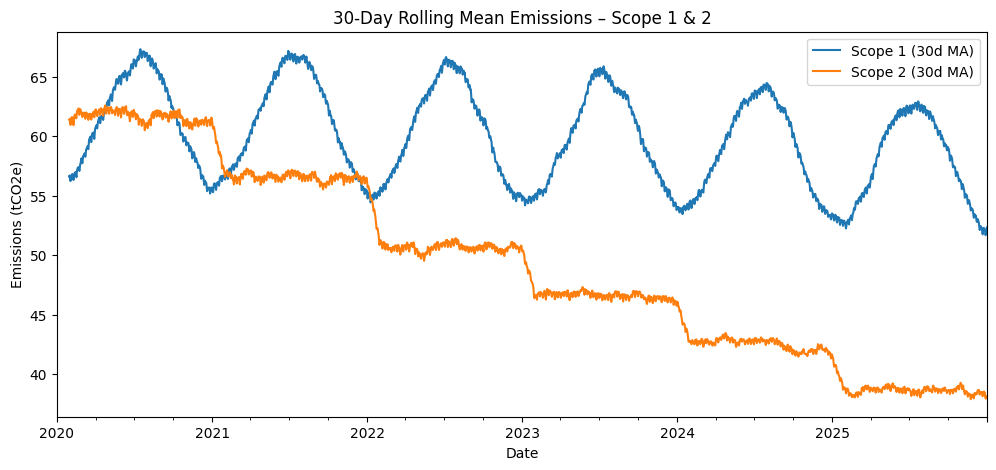

In [ ]:
#Adding rolling means to smooth noise
#Helps to see long‑term trend and seasonality

plt.figure(figsize=(12, 5))
for scope in ["Scope 1", "Scope 2"]:
    mask = daily_scope["Emission_Type"] == scope
    series = (daily_scope[mask]
              .set_index("Date")["Emissions_tCO2e"]
              .sort_index()
              .rolling(30).mean())  # 30-day rolling

    series.plot(label=f"{scope} (30d MA)")

plt.title("30-Day Rolling Mean Emissions – Scope 1 & 2")
plt.ylabel("Emissions (tCO2e)")
plt.legend()
plt.show()


In [5]:
#Missing days per scope

scope1_dates = set(daily_scope[daily_scope["Emission_Type"] == "Scope 1"]["Date"])
scope2_dates = set(daily_scope[daily_scope["Emission_Type"] == "Scope 2"]["Date"])

missing_in_s1 = sorted(scope2_dates - scope1_dates)
missing_in_s2 = sorted(scope1_dates - scope2_dates)

len(missing_in_s1), len(missing_in_s2)


(0, 0)

In [6]:
#Building a small anomaly register

anomalies = daily_scope[daily_scope["is_outlier"]].copy()
anomalies = anomalies.sort_values(["Emission_Type", "Date"])

anomalies.head()
len(anomalies)


0

In [7]:
#store the “anomaly register” even if empty

ANOMALY_PATH = "../data/processed/anomaly_register_daily.csv"
anomalies.to_csv(ANOMALY_PATH, index=False)


In [14]:
DATA_PATH = "C:\\AMDARI PROJECTS\\NEXYGEN\\nexygen-emissions-forecasting\\data\\raw\\ESG_Data.csv" 

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["Date"],
)

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 236736 entries, 0 to 236735
Data columns (total 12 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   Date                              236736 non-null  datetime64[us]
 1   Year                              236736 non-null  int64         
 2   Asset_ID                          236736 non-null  str           
 3   Asset_Type                        236736 non-null  str           
 4   Location                          236736 non-null  str           
 5   Operational_Status                236736 non-null  str           
 6   Energy_Type                       236736 non-null  str           
 7   Consumption_Units                 236736 non-null  float64       
 8   Emission_Type                     236736 non-null  str           
 9   Emissions_tCO2e                   236736 non-null  float64       
 10  Target_Emissions_tCO2e            236736 no

In [15]:
df.groupby("Emission_Type")["Emissions_tCO2e"].sum()


Emission_Type
Scope 1    131129.696790
Scope 2    108364.355412
Name: Emissions_tCO2e, dtype: float64

In [ ]:
#monthly forecasting table
monthly_scope = (
    daily_scope
    .groupby([
        pd.Grouper(key="Date", freq="ME"),
        "Emission_Type"
    ], as_index=False)
    .agg(
        Emissions_tCO2e=("Emissions_tCO2e", "sum"),
        Consumption_Units=("Consumption_Units", "sum")
    )
)

monthly_scope["Year"] = monthly_scope["Date"].dt.year
monthly_scope["Month"] = monthly_scope["Date"].dt.month

monthly_scope.head()

# Save
monthly_scope.to_csv("../data/processed/monthly_scope.csv", index=False)


c:\AMDARI PROJECTS\NEXYGEN\nexygen-emissions-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


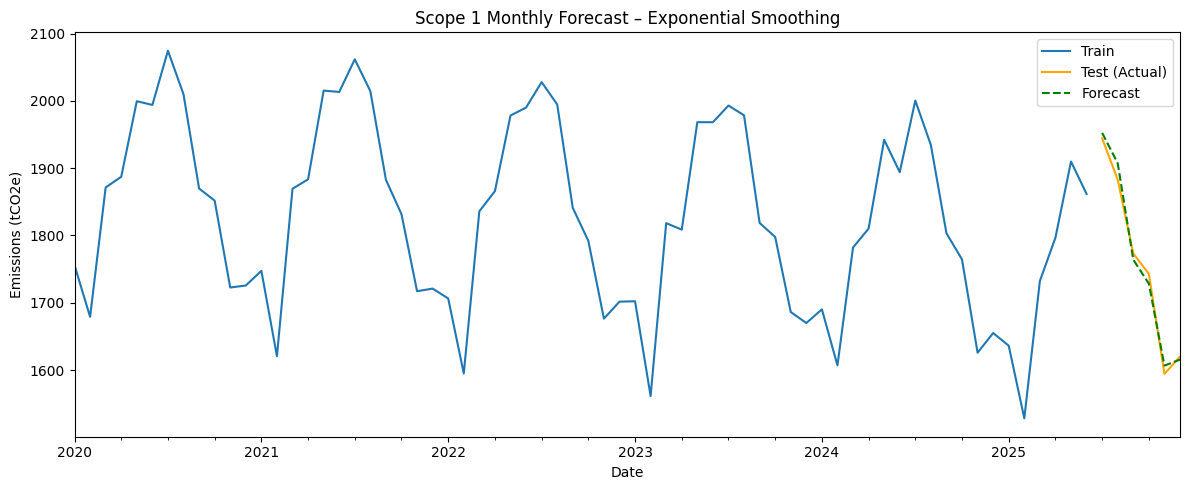

Scope 1 MAE: 12.10 tCO2e
Scope 1 MAPE: 0.68%


In [20]:
# Baseline forecast (Exponential Smoothing)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Scope 1 monthly series
s1_monthly = monthly_scope[monthly_scope["Emission_Type"] == "Scope 1"].set_index("Date")["Emissions_tCO2e"].sort_index()

# Train on all but last 6 months
train = s1_monthly[:-6]
test = s1_monthly[-6:]

# Fit model
model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12)
fit = model.fit()

# Forecast
forecast = fit.forecast(steps=len(test))

# Plot
plt.figure(figsize=(12, 5))
train.plot(label="Train")
test.plot(label="Test (Actual)", color="orange")
forecast.plot(label="Forecast", color="green", linestyle="--")
plt.title("Scope 1 Monthly Forecast – Exponential Smoothing")
plt.ylabel("Emissions (tCO2e)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/scope1_forecast.png", dpi=150)
plt.show()

# Accuracy
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
mae = mean_absolute_error(test, forecast)
mape = mean_absolute_percentage_error(test, forecast) * 100

print(f"Scope 1 MAE: {mae:.2f} tCO2e")
print(f"Scope 1 MAPE: {mape:.2f}%")


c:\AMDARI PROJECTS\NEXYGEN\nexygen-emissions-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


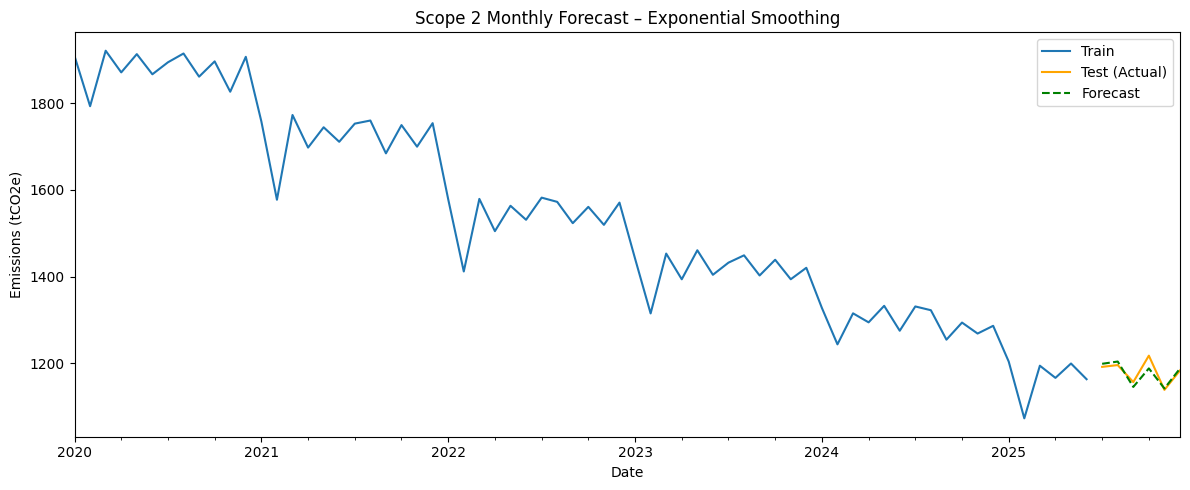

Scope 2 MAE: 10.57 tCO2e
Scope 2 MAPE: 0.88%


In [21]:
# For Scope 2
s2_monthly = monthly_scope[monthly_scope["Emission_Type"] == "Scope 2"].set_index("Date")["Emissions_tCO2e"].sort_index()
train2 = s2_monthly[:-6]
test2 = s2_monthly[-6:]

model2 = ExponentialSmoothing(train2, trend="add", seasonal="add", seasonal_periods=12)
fit2 = model2.fit()
forecast2 = fit2.forecast(steps=len(test2))

plt.figure(figsize=(12, 5))
train2.plot(label="Train")
test2.plot(label="Test (Actual)", color="orange")
forecast2.plot(label="Forecast", color="green", linestyle="--")
plt.title("Scope 2 Monthly Forecast – Exponential Smoothing")
plt.ylabel("Emissions (tCO2e)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/scope2_forecast.png", dpi=150)
plt.show()

mae2 = mean_absolute_error(test2, forecast2)
mape2 = mean_absolute_percentage_error(test2, forecast2) * 100
print(f"Scope 2 MAE: {mae2:.2f} tCO2e")
print(f"Scope 2 MAPE: {mape2:.2f}%")


In [22]:
results = {
    "Scope": ["Scope 1", "Scope 2"],
    "MAE (tCO2e)": [mae, mae2],
    "MAPE (%)": [mape, mape2]
}

results_df = pd.DataFrame(results)
results_df.to_csv("../data/processed/forecast_results.csv", index=False)
results_df


,Scope,MAE (tCO2e),MAPE (%)
0,Scope 1,12.104344,0.681693
1,Scope 2,10.568313,0.884868


In [23]:
import joblib

# Save fitted models
joblib.dump(fit, "../data/processed/scope1_model.pkl")
joblib.dump(fit2, "../data/processed/scope2_model.pkl")


['../data/processed/scope2_model.pkl']